# 1. Import Module   

In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
%reload_ext autoreload
%autoreload 2
def warn(*args, **kwargs):
    pass 
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys

from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle

Draw.DrawingOptions.atomLabelFontFace = "DejaVu Sans"
Draw.DrawingOptions.atomLabelFontSize = 18




Failed to find the pandas get_adjustment() function to patch
Failed to patch pandas - PandasTools will have limited functionality


# 2. Load data

In [5]:
file = "C:/Users/USER-PC/QSAR_Code/Dermal toxicity/dataset/dermal_toxicity.sdf"
sdfInfo = dict(smilesName='SMILES',molColName='ROMol')
moldf = PandasTools.LoadSDF(file,**sdfInfo)
print(moldf.shape)
moldf = moldf.rename(columns={'ROMol': 'Mol'})
moldf = moldf[pd.notnull(moldf['Mol'])]
print(moldf.shape)
moldf.keys()

[14:59:17] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5
[14:59:17] ERROR: Could not sanitize molecule ending on line 17927
[14:59:17] ERROR: Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5
[14:59:17] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 14 15 16
[14:59:17] ERROR: Could not sanitize molecule ending on line 27790
[14:59:17] ERROR: Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 14 15 16
[14:59:17] Can't kekulize mol.  Unkekulized atoms: 0 1 2 12 14 15 16 17 20
[14:59:17] ERROR: Could not sanitize molecule ending on line 37933
[14:59:17] ERROR: Can't kekulize mol.  Unkekulized atoms: 0 1 2 12 14 15 16 17 20
Failed to patch pandas - unable to change molecule rendering


(629, 9)
(629, 9)


Index(['CASRN', 'LD50', 'Compound name', 'Binary', 'GHS', 'Set', 'ID',
       'SMILES', 'Mol'],
      dtype='object')

In [6]:
moldf = moldf.rename(columns={'Binary': 'Outcome'})

In [7]:
moldf.head(1)

,CASRN,LD50,Compound name,Outcome,GHS,Set,ID,SMILES,Mol
0,351-05-3,7,,1.0,1,ms,,O=C(CF)Nc1ccc(Br)cc1,<rdkit.Chem.rdchem.Mol object at 0x00000200E5B...


In [8]:
moldf= moldf.sort_values(['Outcome'], ascending=True)
moldf['RowID'] = moldf.index
moldf.head(100)

,CASRN,LD50,Compound name,Outcome,GHS,Set,ID,SMILES,Mol,RowID
631,,2000,Tecnazene,0.0,5,ms,,O=[N+]([O-])c1c(Cl)c(Cl)cc(Cl)c1Cl,<rdkit.Chem.rdchem.Mol object at 0x00000200E6C...,631
418,374067-80-8,2000,unnamed [374067-80-8],0.0,5,ms,,N#Cc1ccc(Nc2nc(=O)cc(O)[nH]2)cc1,<rdkit.Chem.rdchem.Mol object at 0x00000200E5C...,418
419,126990-35-0,2000,dicyclopentyldimethoxysilane,0.0,5,ms,,CO[Si](OC)(C1CCCC1)C1CCCC1,<rdkit.Chem.rdchem.Mol object at 0x00000200E5C...,419
420,1933-50-2,4000,"AC-24,055",0.0,5,ms,,CC(=O)Nc1ccc(N=NN(C)C)cc1,<rdkit.Chem.rdchem.Mol object at 0x00000200E5C...,420
421,76950-43-1,2000,"1,4-diazabicyclo[2.2.2]octan-2-ylmethanol",0.0,5,ms,,OCC1CN2CCN1CC2,<rdkit.Chem.rdchem.Mol object at 0x00000200E5C...,421
...,...,...,...,...,...,...,...,...,...,...
336,188113-71-5,2000,unnamed [188113-71-5],0.0,5,ms,,CC(=O)n1cc(CC2CCCN2C)c2cc(C=CS(=O)(=O)c3ccccc3...,<rdkit.Chem.rdchem.Mol object at 0x00000200E5C...,336
335,101903-30-4,2000,Pefurazoate [ISO:BSI],0.0,5,ms,,C=CCCCOC(=O)C(CC)N(Cc1ccco1)C(=O)n1ccnc1,<rdkit.Chem.rdchem.Mol object at 0x00000200E5C...,335
334,6259-53-6,2000,4-hydroxy-6-(methylamino)naphthalene-2-sulfoni...,0.0,5,ms,,CCN(CC)S(=O)(=O)c1ccc(C(=O)NCc2ccc3c(c2)cc(C)n...,<rdkit.Chem.rdchem.Mol object at 0x00000200E5C...,334
317,182061-89-8,2000,-,0.0,5,ms,,N=C1C=Cc2cc(S(=O)(=O)O)cc(O)c2C1=NNc1ccc(Nc2nc...,<rdkit.Chem.rdchem.Mol object at 0x00000200E5C...,317


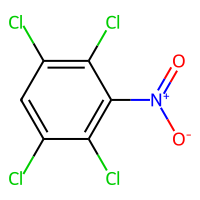

O=[N+]([O-])c1c(Cl)c(Cl)cc(Cl)c1Cl


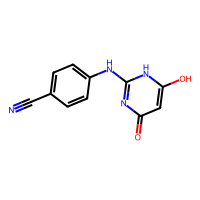

N#Cc1ccc(Nc2nc(=O)cc(O)[nH]2)cc1


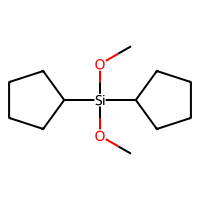

CO[Si](OC)(C1CCCC1)C1CCCC1


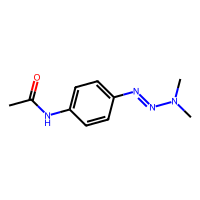

CC(=O)Nc1ccc(N=NN(C)C)cc1


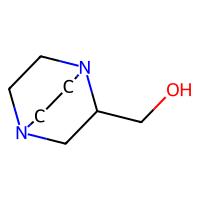

OCC1CN2CCN1CC2


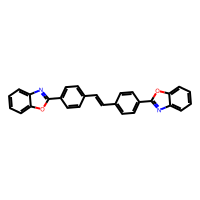

C(=Cc1ccc(-c2nc3ccccc3o2)cc1)c1ccc(-c2nc3ccccc3o2)cc1


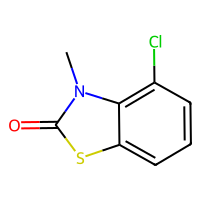

Cn1c(=O)sc2cccc(Cl)c21


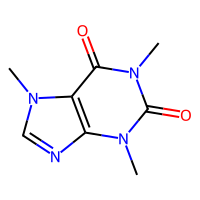

Cn1c(=O)c2c(ncn2C)n(C)c1=O


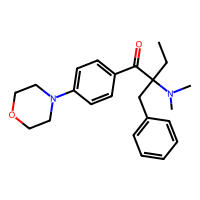

CCC(Cc1ccccc1)(C(=O)c1ccc(N2CCOCC2)cc1)N(C)C


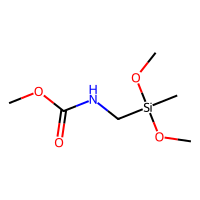

COC(=O)NC[Si](C)(OC)OC


In [6]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

def display_molecules_in_column(moldf, num_mols):
    for _, row in moldf.head(num_mols).iterrows():
        smi = row['SMILES']
        if smi is not None:
            mol = Chem.MolFromSmiles(smi)  # Create Mol object from SMILES
            if mol is not None:
                img = Draw.MolToImage(mol, size=(200, 200))
                display(img)
                print(smi)  # Prints the SMILES representation below the image

# Assuming 'df' is your DataFrame
# Display the first 10 molecules, each on a new row
display_molecules_in_column(moldf, 10)


In [7]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from mordred import Calculator, descriptors
from fancyimpute import KNN


(CVXPY) Sep 11 05:20:08 PM: Encountered unexpected exception importing solver CVXOPT:
ImportError('DLL load failed while importing base: The specified module could not be found.')
(CVXPY) Sep 11 05:20:08 PM: Encountered unexpected exception importing solver GLPK:
ImportError('DLL load failed while importing base: The specified module could not be found.')
(CVXPY) Sep 11 05:20:08 PM: Encountered unexpected exception importing solver GLPK_MI:
ImportError('DLL load failed while importing base: The specified module could not be found.')


## 3. Morgan, MACCsKeys, Modred

In [8]:
# Morgan fingerprints
nBits = 1024
radius = 2
useFeatures = False
moldf['Morgan_Descriptors'] = moldf['Mol'].apply(lambda mol: AllChem.GetMorganFingerprintAsBitVect(mol, nBits=nBits, radius=radius, useFeatures=useFeatures))

# MACCS keys
moldf['MACCS_Descriptors'] = moldf['Mol'].apply(lambda mol: MACCSkeys.GenMACCSKeys(mol))



In [9]:
from sklearn.preprocessing import StandardScaler
from rdkit import Chem
from mordred import Calculator, descriptors

# create descriptor calculator with all descriptors
calc = Calculator(descriptors, ignore_3D=True)
df = calc.pandas(moldf['Mol'])

  3%|▎         | 19/629 [00:03<00:57, 10.58it/s]

C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 10%|▉         | 60/629 [00:03<00:14, 38.13it/s]

C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 19%|█▉        | 121/629 [00:05<00:17, 29.59it/s]

C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 62%|██████▏   | 391/629 [00:08<00:02, 89.81it/s]

C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


100%|██████████| 629/629 [00:11<00:00, 56.71it/s] 


In [10]:
from fancyimpute import KNN
import pandas as pd
import numpy as np


df_numeric = df.select_dtypes(include=[float])  
df_filled = pd.DataFrame(KNN(k=3).fit_transform(df_numeric), columns=df_numeric.columns, index=df_numeric.index)


Imputing row 1/629 with 0 missing, elapsed time: 0.563
Imputing row 101/629 with 0 missing, elapsed time: 0.563
Imputing row 201/629 with 0 missing, elapsed time: 0.563
Imputing row 301/629 with 0 missing, elapsed time: 0.563
Imputing row 401/629 with 0 missing, elapsed time: 0.564
Imputing row 501/629 with 0 missing, elapsed time: 0.564
Imputing row 601/629 with 0 missing, elapsed time: 0.564


In [11]:
X = np.array(df_filled)
scaler = StandardScaler()
x=  scaler.fit_transform(X)
moldf['Modred_Descriptor'] = x.tolist()

In [12]:
print(x.shape)

(629, 794)


In [13]:
moldf

,CASRN,LD50,Compound name,Outcome,GHS,Set,ID,SMILES,Mol,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor
631,,2000,Tecnazene,0.0,5,ms,,O=[N+]([O-])c1c(Cl)c(Cl)cc(Cl)c1Cl,<rdkit.Chem.rdchem.Mol object at 0x000002B4B4D...,631,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.5274688001992828, 0.4802242875417483, 0.58..."
418,374067-80-8,2000,unnamed [374067-80-8],0.0,5,ms,,N#Cc1ccc(Nc2nc(=O)cc(O)[nH]2)cc1,<rdkit.Chem.rdchem.Mol object at 0x000002B4B3D...,418,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.012667065071603813, 0.04521339577840898, 0..."
419,126990-35-0,2000,dicyclopentyldimethoxysilane,0.0,5,ms,,CO[Si](OC)(C1CCCC1)C1CCCC1,<rdkit.Chem.rdchem.Mol object at 0x000002B4B3D...,419,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.14774342608322746, 0.7392197142034025, 0.6..."
420,1933-50-2,4000,"AC-24,055",0.0,5,ms,,CC(=O)Nc1ccc(N=NN(C)C)cc1,<rdkit.Chem.rdchem.Mol object at 0x000002B4B3D...,420,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.2925231113992596, -0.2356232856012222, -0...."
421,76950-43-1,2000,"1,4-diazabicyclo[2.2.2]octan-2-ylmethanol",0.0,5,ms,,OCC1CN2CCN1CC2,<rdkit.Chem.rdchem.Mol object at 0x000002B4B3D...,421,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.6356224494744906, 0.32891204489908815, 0.4..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,52756-25-9,294,Flamprop-methyl [ISO],1.0,3,ms,,COC(=O)C(C)N(C(=O)c1ccccc1)c1ccc(F)c(Cl)c1,<rdkit.Chem.rdchem.Mol object at 0x000002B4B3D...,210,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.6503475250869725, 0.5379077664424231, 0.644..."
211,644-64-4,600,Dimetilan [BSI],1.0,3,ms,,Cc1cc(OC(=O)N(C)C)nn1C(=O)N(C)C,<rdkit.Chem.rdchem.Mol object at 0x000002B4B3D...,211,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.12797074972456784, 0.4017787022406476, 0.0..."
212,13171-21-6,125,cis-Phosphamidon,1.0,2,ms,,CCN(CC)C(=O)C(Cl)=C(C)OP(=O)(OC)OC,<rdkit.Chem.rdchem.Mol object at 0x000002B4B3D...,212,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.02170892685873513, 0.10871711914876081, 0...."
205,2275-18-5,100,Prothoate [BSI:ISO],1.0,2,ms,,CCOP(=S)(OCC)SCC(=O)NC(C)C,<rdkit.Chem.rdchem.Mol object at 0x000002B4B3D...,205,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.2925455293013956, -0.18417506006678774, -0..."


In [14]:
moldf.keys()

Index(['CASRN', 'LD50', 'Compound name', 'Outcome', 'GHS', 'Set', 'ID',
       'SMILES', 'Mol', 'RowID', 'Morgan_Descriptors', 'MACCS_Descriptors',
       'Modred_Descriptor'],
      dtype='object')

In [15]:
data = moldf.drop(columns=['CASRN', 'LD50', 'Compound name','GHS', 'Set', 'ID',])

In [16]:
data

,Outcome,SMILES,Mol,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor
631,0.0,O=[N+]([O-])c1c(Cl)c(Cl)cc(Cl)c1Cl,<rdkit.Chem.rdchem.Mol object at 0x000002B4B4D...,631,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.5274688001992828, 0.4802242875417483, 0.58..."
418,0.0,N#Cc1ccc(Nc2nc(=O)cc(O)[nH]2)cc1,<rdkit.Chem.rdchem.Mol object at 0x000002B4B3D...,418,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.012667065071603813, 0.04521339577840898, 0..."
419,0.0,CO[Si](OC)(C1CCCC1)C1CCCC1,<rdkit.Chem.rdchem.Mol object at 0x000002B4B3D...,419,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.14774342608322746, 0.7392197142034025, 0.6..."
420,0.0,CC(=O)Nc1ccc(N=NN(C)C)cc1,<rdkit.Chem.rdchem.Mol object at 0x000002B4B3D...,420,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.2925231113992596, -0.2356232856012222, -0...."
421,0.0,OCC1CN2CCN1CC2,<rdkit.Chem.rdchem.Mol object at 0x000002B4B3D...,421,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.6356224494744906, 0.32891204489908815, 0.4..."
...,...,...,...,...,...,...,...
210,1.0,COC(=O)C(C)N(C(=O)c1ccccc1)c1ccc(F)c(Cl)c1,<rdkit.Chem.rdchem.Mol object at 0x000002B4B3D...,210,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.6503475250869725, 0.5379077664424231, 0.644..."
211,1.0,Cc1cc(OC(=O)N(C)C)nn1C(=O)N(C)C,<rdkit.Chem.rdchem.Mol object at 0x000002B4B3D...,211,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.12797074972456784, 0.4017787022406476, 0.0..."
212,1.0,CCN(CC)C(=O)C(Cl)=C(C)OP(=O)(OC)OC,<rdkit.Chem.rdchem.Mol object at 0x000002B4B3D...,212,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.02170892685873513, 0.10871711914876081, 0...."
205,1.0,CCOP(=S)(OCC)SCC(=O)NC(C)C,<rdkit.Chem.rdchem.Mol object at 0x000002B4B3D...,205,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.2925455293013956, -0.18417506006678774, -0..."


In [17]:
data.keys()

Index(['Outcome', 'SMILES', 'Mol', 'RowID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor'],
      dtype='object')

# 4. Split into Train and Test Data and Save into sdf file

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect



# Remove duplicate columns
data = data.loc[:, ~data.columns.duplicated()]

# Split the data into train and test sets
train, test = train_test_split(data, test_size=0.2, random_state=42)

# Function to convert bit vectors to a list of integers
def bitvector_to_list(bitvector):
    if isinstance(bitvector, ExplicitBitVect):
        return list(map(int, bitvector.ToBitString()))
    else:
        return bitvector

# Convert bit vectors to lists before saving
def convert_bit_vectors(df):
    if 'Morgan_Descriptors' in df.columns:
        df['Morgan_Descriptors'] = df['Morgan_Descriptors'].apply(bitvector_to_list)
    if 'MACCS_Descriptors' in df.columns:
        df['MACCS_Descriptors'] = df['MACCS_Descriptors'].apply(bitvector_to_list)
    return df

# Convert bit vectors for train and test sets
train = convert_bit_vectors(train)
test = convert_bit_vectors(test)

# Function to save DataFrame to SDF
def save_to_sdf(df, filename):
    sdf_writer = Chem.SDWriter(filename)
    for idx, row in df.iterrows():
        mol = Chem.MolFromSmiles(row['SMILES'])
        if mol is not None:
            mol.SetProp("_Name", str(idx))
            for col in df.columns:
                if col != 'Mol' and col != 'SMILES':
                    mol.SetProp(col, str(row[col]))
            sdf_writer.write(mol)
    sdf_writer.close()


# Save the train and test sets to SDF files
save_to_sdf(train, 'C:/Users/USER-PC/QSAR_Code/Dermal toxicity/dataset/train_set_acute_dermal_features.sdf')
save_to_sdf(test, 'C:/Users/USER-PC/QSAR_Code/Dermal toxicity/dataset/test_set_acute_dermal_features.sdf')

print("Train and test sets saved to 'train_set.sdf' and 'test_set.sdf' respectively.")


Train and test sets saved to 'train_set.sdf' and 'test_set.sdf' respectively.


In [19]:
# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the train and test sets from SDF files
train_df = load_sdf_to_df('C:/Users/USER-PC/QSAR_Code/Dermal toxicity/dataset/train_set_acute_dermal_features.sdf')
test_df = load_sdf_to_df('C:/Users/USER-PC/QSAR_Code/Dermal toxicity/dataset/test_set_acute_dermal_features.sdf')


# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

train_df['Morgan_Descriptors'] = train_df['Morgan_Descriptors'].apply(string_to_list)
test_df['Morgan_Descriptors'] = test_df['Morgan_Descriptors'].apply(string_to_list)
train_df['MACCS_Descriptors'] = train_df['MACCS_Descriptors'].apply(string_to_list)
test_df['MACCS_Descriptors'] = test_df['MACCS_Descriptors'].apply(string_to_list)

print("Train DataFrame:")
print(train_df.head())

print("Test DataFrame:")
print(test_df.head())


Train DataFrame:
  Outcome RowID                                 Morgan_Descriptors  \
0     1.0    97  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1     0.0   423  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2     0.0   324  [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...   
3     0.0   326  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...   
4     1.0   271  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   Modred_Descriptor  \
0  [-0.7571533001292252, 0.10071006172030744, -0....   
1  [-0.5229944546265503, 0.6945944968901582, 0.43...   
2  [2.4933180487465414, 1.0087818088201828, 1.136...   
3

In [20]:
train_df

,Outcome,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,SMILES
0,1.0,97,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7571533001292252, 0.10071006172030744, -0....",c1ccc2scnc2c1
1,0.0,423,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.5229944546265503, 0.6945944968901582, 0.43...",Cn1c(=O)sc2cccc(Cl)c21
2,0.0,324,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2.4933180487465414, 1.0087818088201828, 1.136...",CC1=NN(c2ccc(S(=O)(=O)CCOS(=O)(=O)O)cc2)C(=O)C...
3,0.0,326,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.8933498350280953, 0.808547856238841, 0.6547...",O=C(O)c1[nH]n(-c2ccc(S(=O)(=O)O)cc2)c(=O)c1/N=...
4,1.0,271,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.5636934239974323, -0.30288732329230866, -0...",CNC(=O)Oc1cccc(C)c1
...,...,...,...,...,...,...
498,0.0,449,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7293999503826913, -0.24506805534357434, -0...",C=CC(=O)NC(C)(C)CC(C)=O
499,0.0,325,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2.634174382383606, 1.2726891199107406, 1.4256...",Cc1c(Nc2cc(S(=O)(=O)O)c(N)c3c2C(=O)c2ccccc2C3=...
500,0.0,490,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.14655243797978876, 0.663417375980514, 0.65...",O=C1CC(C(=O)O)CC(O)=C1C(=O)C1CC1
501,1.0,62,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.1914091212954949, 0.33856452167033163, 0.43...",CCOP(=O)(OCC)OC(=CCl)c1ccc(Cl)cc1Cl


In [21]:
train

,Outcome,SMILES,Mol,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor
97,1.0,c1ccc2scnc2c1,<rdkit.Chem.rdchem.Mol object at 0x000002B4B3D...,97,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7571533001292252, 0.10071006172030744, -0...."
423,0.0,Cn1c(=O)sc2cccc(Cl)c21,<rdkit.Chem.rdchem.Mol object at 0x000002B4B3D...,423,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.5229944546265503, 0.6945944968901582, 0.43..."
324,0.0,CC1=NN(c2ccc(S(=O)(=O)CCOS(=O)(=O)O)cc2)C(=O)C...,<rdkit.Chem.rdchem.Mol object at 0x000002B4B3D...,324,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2.4933180487465414, 1.0087818088201828, 1.136..."
326,0.0,O=C(O)c1[nH]n(-c2ccc(S(=O)(=O)O)cc2)c(=O)c1/N=...,<rdkit.Chem.rdchem.Mol object at 0x000002B4B3D...,326,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.8933498350280953, 0.808547856238841, 0.6547..."
271,1.0,CNC(=O)Oc1cccc(C)c1,<rdkit.Chem.rdchem.Mol object at 0x000002B4B3D...,271,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.5636934239974323, -0.30288732329230866, -0..."
...,...,...,...,...,...,...,...
449,0.0,C=CC(=O)NC(C)(C)CC(C)=O,<rdkit.Chem.rdchem.Mol object at 0x000002B4B3D...,449,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7293999503826913, -0.24506805534357434, -0..."
325,0.0,Cc1c(Nc2cc(S(=O)(=O)O)c(N)c3c2C(=O)c2ccccc2C3=...,<rdkit.Chem.rdchem.Mol object at 0x000002B4B3D...,325,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2.634174382383606, 1.2726891199107406, 1.4256..."
490,0.0,O=C1CC(C(=O)O)CC(O)=C1C(=O)C1CC1,<rdkit.Chem.rdchem.Mol object at 0x000002B4B3D...,490,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.14655243797978876, 0.663417375980514, 0.65..."
62,1.0,CCOP(=O)(OCC)OC(=CCl)c1ccc(Cl)cc1Cl,<rdkit.Chem.rdchem.Mol object at 0x000002B4B3C...,62,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.1914091212954949, 0.33856452167033163, 0.43..."
